In [ ]:
# Mounting drive

from google.colab import drive
drive.mount('/content/drive')
!pip install mne

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Checking the path in drive

import os

# Your specified dataset directory
dataset_dir = '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG'

print(f"Checking directory: '{dataset_dir}'")

if not os.path.exists(dataset_dir):
    print(f"Error: The directory '{dataset_dir}' does not exist. Please double-check the path.")
elif not os.path.isdir(dataset_dir):
    print(f"Error: '{dataset_dir}' is not a directory. Please provide a valid directory path.")
else:
    # List all entries (files and directories) in the specified directory
    all_entries = os.listdir(dataset_dir)

    if not all_entries:
        print(f"The directory '{dataset_dir}' is empty.")
    else:
        print(f"\nAll files and subdirectories in '{dataset_dir}':")
        for i, entry in enumerate(all_entries):
            print(f"  {i+1}. {entry}")

        # Filter for .bdf files
        bdf_files = [f for f in all_entries if f.endswith('.bdf')]

        if bdf_files:
            print(f"\nFound {len(bdf_files)} .bdf files in '{dataset_dir}':")
            for i, file_name in enumerate(bdf_files):
                print(f"  {i+1}. {file_name}")
            print("\nPlease select one file to start preprocessing, or confirm if you'd like to process all of them.")
            print("For example, you can choose the first file: `selected_bdf_file = os.path.join(dataset_dir, bdf_files[0])`")
        else:
            print(f"\nNo .bdf files found directly in the specified directory: '{dataset_dir}'.")
            print("Please ensure the files are directly in this folder and have the `.bdf` extension.")


Checking directory: '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG'

All files and subdirectories in '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG':
  1. CHANGES
  2. README
  3. dataset_description.json
  4. participants.json
  5. task-rest_beh.json
  6. participants.tsv
  7. sub-pd5
  8. sub-pd3
  9. sub-pd23
  10. sub-pd22
  11. sub-pd26
  12. sub-pd6
  13. sub-pd19
  14. sub-pd28
  15. sub-pd9
  16. sub-pd17
  17. sub-pd14
  18. sub-pd16
  19. sub-hc31
  20. sub-pd13
  21. sub-hc8
  22. sub-pd12
  23. sub-hc7
  24. sub-hc30
  25. sub-pd11
  26. sub-hc4
  27. sub-hc33
  28. sub-hc32
  29. sub-hc29
  30. sub-hc21
  31. sub-hc24
  32. sub-hc25
  33. sub-hc20
  34. sub-hc2
  35. sub-hc18
  36. sub-hc10
  37. sub-hc1
  38. preprocessed_epochs

No .bdf files found directly in the specified directory: '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG'.
Please ensure the files are directly in this folder and have the `.bdf` extension.


In [ ]:
# Checking inside the san diego files for .bdf files

import os

dataset_dir = '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG'
all_bdf_files = []

print(f"Searching for .bdf files recursively in: '{dataset_dir}'...")

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith('.bdf'):
            all_bdf_files.append(os.path.join(root, file))

if all_bdf_files:
    print(f"\nFound {len(all_bdf_files)} .bdf files:")
    for i, file_path in enumerate(all_bdf_files):
        print(f"  {i+1}. {file_path}")
    print("\nPlease review the list and confirm which file(s) you would like to preprocess first. You can select a single file path from this list for the next steps.")
else:
    print(f"\nNo .bdf files found in '{dataset_dir}' or any of its subdirectories. Please double-check the base path and the file structure.")


Searching for .bdf files recursively in: '/content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG'...

Found 46 .bdf files:
  1. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd5/ses-on/eeg/sub-pd5_ses-on_task-rest_eeg.bdf
  2. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd5/ses-off/eeg/sub-pd5_ses-off_task-rest_eeg.bdf
  3. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd3/ses-off/eeg/sub-pd3_ses-off_task-rest_eeg.bdf
  4. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd3/ses-on/eeg/sub-pd3_ses-on_task-rest_eeg.bdf
  5. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd23/ses-on/eeg/sub-pd23_ses-on_task-rest_eeg.bdf
  6. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd23/ses-off/eeg/sub-pd23_ses-off_task-rest_eeg.bdf
  7. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd22/ses-on/eeg/sub-pd22_ses-on_task-rest_eeg.bdf
  8. /content/drive/MyDrive/Parkinson_EEG_Project/SanDieg

In [ ]:
# Filtering the list to show only ses-off and ses-hc files

filtered_bdf_files = []
for file_path in all_bdf_files:
    if 'ses-off' in file_path or 'ses-hc' in file_path:
        filtered_bdf_files.append(file_path)

if filtered_bdf_files:
    print(f"Found {len(filtered_bdf_files)} .bdf files for 'ses-off' or 'ses-hc' conditions:")
    for i, file_path in enumerate(filtered_bdf_files):
        print(f"  {i+1}. {file_path}")
    print("\nPlease select one file from this filtered list to begin preprocessing.")
else:
    print("No .bdf files matching 'ses-off' or 'ses-hc' conditions were found.")

Found 31 .bdf files for 'ses-off' or 'ses-hc' conditions:
  1. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd5/ses-off/eeg/sub-pd5_ses-off_task-rest_eeg.bdf
  2. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd3/ses-off/eeg/sub-pd3_ses-off_task-rest_eeg.bdf
  3. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd23/ses-off/eeg/sub-pd23_ses-off_task-rest_eeg.bdf
  4. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd22/ses-off/eeg/sub-pd22_ses-off_task-rest_eeg.bdf
  5. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd26/ses-off/eeg/sub-pd26_ses-off_task-rest_eeg.bdf
  6. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd6/ses-off/eeg/sub-pd6_ses-off_task-rest_eeg.bdf
  7. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd19/ses-off/eeg/sub-pd19_ses-off_task-rest_eeg.bdf
  8. /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd28/ses-off/eeg/sub-pd28_ses-off_task-rest_eeg.

In [ ]:
import mne
import numpy as np
import os

output_base_dir = '/content/drive/MyDrive/Preprocessed_EEG_SanDiego/'
os.makedirs(output_base_dir, exist_ok=True)

print(f"Starting preprocessing for {len(filtered_bdf_files)} files...")

for i, data_path in enumerate(filtered_bdf_files):
    print(f"\n--- Processing file {i+1}/{len(filtered_bdf_files)}: {os.path.basename(data_path)} ---")

    raw = None # Initialize raw to None for each iteration

    try:
        # Load the .bdf file
        # Adjust eog and misc channels based on your data if necessary
        raw = mne.io.read_raw_bdf(data_path, preload=True, eog=['EXG1', 'EXG2', 'EXG3', 'EXG4'], misc=['EXG5', 'EXG6', 'EXG7', 'EXG8'])
        print(f"Successfully loaded data from: {os.path.basename(data_path)}")

        # 1. Channel Selection and Renaming
        # Keep EOG channels for ICA artifact detection, exclude 'bads' initially
        raw.pick_types(eeg=True, eog=True, exclude='bads')
        print("Dropped non-EEG/non-EOG channels.")

        # Set standard 10-20 montage
        try:
            montage = mne.channels.make_standard_montage('standard_1020')
            raw.set_montage(montage, on_missing='ignore')
            print("Standard 10-20 montage applied.")
        except Exception as e:
            print(f"Could not apply standard 10-20 montage: {e}. Proceeding without it.")

        # 2. Filtering (0.5 to 40 Hz band-pass)
        l_freq, h_freq = 0.5, 40.0
        raw.filter(l_freq, h_freq, fir_design='firwin', skip_by_annotation='edge')
        print(f"Applied band-pass filter: {l_freq}-{h_freq} Hz.")

        # 3. Re-referencing (Common Average Reference)
        # Temporarily pick only EEG channels for re-referencing to avoid issues with EOG/MISC in average
        eeg_channels_only = raw.copy().pick_types(eeg=True)
        eeg_channels_only.set_eeg_reference('average', projection=True)
        eeg_channels_only.apply_proj()
        # Apply the projector created from EEG channels to the original raw data (which still has EOG)
        raw.add_proj(eeg_channels_only.info['projs'], remove_existing=True)
        raw.apply_proj()
        print("Applied Common Average Reference (CAR) to EEG channels.")
        del eeg_channels_only # Clean up temporary object

        # 4. ICA for artifact removal (NEW STEP)
        print("Starting ICA artifact removal...")
        ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter='auto')
        ica.fit(raw, picks='eeg') # Fit ICA only on EEG channels

        # Identify EOG artifacts using the dedicated EOG channels
        eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name=['EXG1', 'EXG2'], threshold=3.0)
        if eog_indices:
            ica.exclude.extend(eog_indices)
            print(f"Identified EOG artifacts in components: {eog_indices}")

        # For muscle artifacts, you might need to manually inspect or use a more sophisticated method
        # For now, we'll try a simple frequency-based approach often indicative of muscle.
        # This step is more complex and often requires visual inspection. For automation, a simpler
        # but less precise method can be used or skipped if not critical.
        # muscle_indices, muscle_scores = ica.find_bads_muscle(raw, threshold=3.0) # Requires muscle channels or specific freq characteristics
        # if muscle_indices:
        #     ica.exclude.extend(muscle_indices)
        #     print(f"Identified muscle artifacts in components: {muscle_indices}")

        if ica.exclude:
            ica.apply(raw) # Apply ICA to the raw data
            print(f"Applied ICA to remove {len(ica.exclude)} artifactual components.")
        else:
            print("No artifactual ICA components identified for removal.")

        # After ICA, now pick only EEG channels for subsequent analysis/epoching
        raw.pick_types(eeg=True)
        print("Retained only EEG channels after ICA application.")

        # 5. Epoching (2-second fixed-length epochs)
        tmin, tmax = 0, 2  # start and end of each epoch in seconds
        event_id = 1       # Dummy event ID

        events_from_annot, event_dict = mne.events_from_annotations(raw)
        if not events_from_annot.size:
            events = mne.make_fixed_length_events(raw, id=event_id, start=0, duration=tmax, overlap=0)
            print("Created fixed-length events for epoching.")
        else:
            events = events_from_annot
            print("Using events from annotations for epoching.")

        epochs = mne.Epochs(raw, events, event_id=event_id, tmin=tmin, tmax=tmax,
                            baseline=(0, 0), preload=True, reject_by_annotation=True)
        print(f"Created epochs of {tmax-tmin} seconds.")

        # 6. Baseline Correction (already applied during epoching)
        print("Baseline correction applied during epoching.")

        epochs.drop_bad()
        print(f"Number of good epochs after preprocessing: {len(epochs)}")

        # Save the preprocessed epochs
        original_filename_base = os.path.basename(data_path)
        output_filename = os.path.join(output_base_dir, original_filename_base.replace('.bdf', '_preprocessed-epo.fif'))

        epochs.save(output_filename, overwrite=True)
        print(f"Preprocessed epochs saved to: {output_filename}")

        # Clear memory for the current file
        del raw
        del epochs
        del ica # Delete ICA object as well
        print("Raw, epochs, and ICA objects for current file deleted from memory.")

    except Exception as e:
        print(f"An error occurred while processing {os.path.basename(data_path)}: {e}")
        if raw is not None:
            del raw
        if 'epochs' in locals() and epochs is not None:
            del epochs
        if 'ica' in locals() and ica is not None:
            del ica
        print("Skipping to the next file.")

print("\n--- All selected files have been processed or skipped. ---")
print(f"Preprocessed files are stored in: {output_base_dir}")

Starting preprocessing for 31 files...

--- Processing file 1/31: sub-pd5_ses-off_task-rest_eeg.bdf ---
Extracting BDF parameters from /content/drive/MyDrive/Parkinson_EEG_Project/SanDiego_EEG/sub-pd5/ses-off/eeg/sub-pd5_ses-off_task-rest_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 100863  =      0.000 ...   196.998 secs...
Successfully loaded data from: sub-pd5_ses-off_task-rest_eeg.bdf
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Dropped non-EEG/non-EOG channels.
Standard 10-20 montage applied.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- U

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 5120 samples (10.000 s)

    Applying projection operator with 1 vector (pre-whitener application)
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwi

Loading epochs from: /content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif
Reading /content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =       0.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
98 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated

--- Epochs Info ---
Number of epochs: 98
Data shape (epochs, channels, time points): (98, 32, 1025)
Sampling frequency: 512.0 Hz
Channel names: ['Fp1', 'AF3', 'F7', 'F3', 'FC1']... (first 5 of 32 channels)
Epoch duration: 0.0 to 2.0 seconds
Using matplotlib as 2D backend.


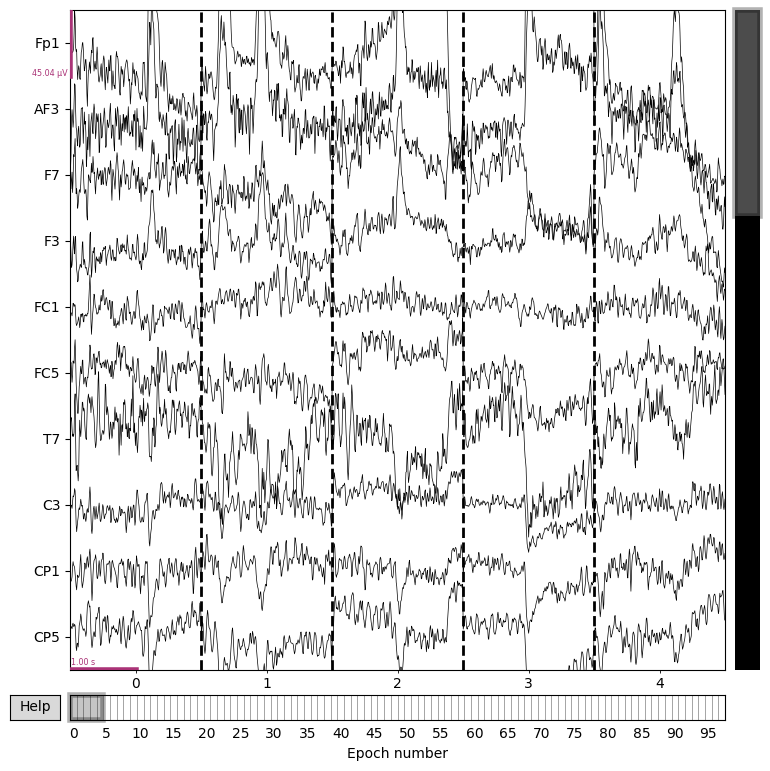

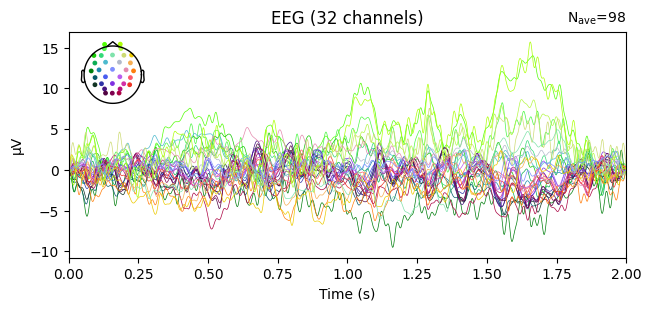

In [ ]:
# Verify preprocessed output
# After the preprocessing cell finishes execution, all your selected .bdf files will have been preprocessed and saved as .fif files in the Preprocessed_EEG_SanDiego folder in your Google Drive. You can use the following cell to load and inspect one of these .fif files to confirm the successful preprocessing.

import mne
import os
import matplotlib.pyplot as plt

# Replace this with the actual path to one of your saved .fif files
# You can choose one from the output of the previous cell, or from your Drive folder.
example_fif_path = '/content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif'

if os.path.exists(example_fif_path):
    print(f"Loading epochs from: {example_fif_path}")
    loaded_epochs = mne.read_epochs(example_fif_path, preload=True)
    print("\n--- Epochs Info ---")
    print(f"Number of epochs: {len(loaded_epochs)}")
    print(f"Data shape (epochs, channels, time points): {loaded_epochs.get_data().shape}")
    print(f"Sampling frequency: {loaded_epochs.info['sfreq']} Hz")
    print(f"Channel names: {loaded_epochs.ch_names[:5]}... (first 5 of {len(loaded_epochs.ch_names)} channels)")
    print(f"Epoch duration: {loaded_epochs.tmin} to {loaded_epochs.tmax} seconds")

    # Optional: Plot a few epochs to visually inspect
    loaded_epochs.plot(n_epochs=5, n_channels=10, scalings='auto', title='Sample Preprocessed Epochs')
    plt.show()

    # Optional: Plot evoked response (average of all epoc hs)
    evoked = loaded_epochs.average()
    evoked.plot(time_unit='s')
    plt.show()

else:
    print(f"Error: {example_fif_path} not found. Please verify the path and ensure the preprocessing has completed.")
    print("Make sure to replace `example_fif_path` with an actual path to a file in your `Preprocessed_EEG_SanDiego` folder.")

In [ ]:
import mne
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the directory where your preprocessed .fif files are stored
output_base_dir = '/content/drive/MyDrive/Preprocessed_EEG_SanDiego/'

# Ensure the output directory exists
os.makedirs(output_base_dir, exist_ok=True)

# List all preprocessed .fif files
fif_files = [os.path.join(output_base_dir, f) for f in os.listdir(output_base_dir) if f.endswith('_preprocessed-epo.fif')]

if not fif_files:
    print(f"No .fif files found in {output_base_dir}. Please ensure the preprocessing step completed successfully.")
else:
    print(f"Found {len(fif_files)} preprocessed .fif files.")
    # Initialize lists to store all epochs and their labels
    all_epochs_data = []
    all_labels = []

    # Iterate through each .fif file, load epochs, and assign labels
    for i, fif_path in enumerate(fif_files):
        try:
            epochs = mne.read_epochs(fif_path, preload=True, verbose=False)

            # Extract label from filename (e.g., 'sub-pdX' for Parkinson's, 'sub-hcX' for Healthy Control)
            filename = os.path.basename(fif_path)
            if 'sub-pd' in filename and 'ses-off' in filename: # Parkinson's patient, 'ses-off' medication
                label = 1  # Parkinson's
            elif 'sub-hc' in filename: # Healthy Control
                label = 0  # Healthy Control
            else:
                # Skip files that don't match the criteria (e.g., 'ses-on' files if not already filtered)
                print(f"Skipping {filename}: Does not match 'ses-off' Parkinson's or 'ses-hc' Healthy Control conditions.")
                continue

            # Append epochs data and labels
            all_epochs_data.append(epochs.get_data(units='uV'))
            all_labels.extend([label] * len(epochs))
            print(f"Loaded {len(epochs)} epochs from {filename} with label {label}.")

        except Exception as e:
            print(f"Error loading {os.path.basename(fif_path)}: {e}")
            continue

    if all_epochs_data:
        # Concatenate all data into a single numpy array
        X = np.concatenate(all_epochs_data, axis=0)
        y = np.array(all_labels)

        print(f"\nTotal combined epochs data shape: {X.shape}")
        print(f"Total combined labels shape: {y.shape}")
        print(f"Class distribution: Healthy Controls (0): {np.sum(y == 0)}, Parkinson's (1): {np.sum(y == 1)}")

        # Standardize the data
        # Reshape X for StandardScaler (channels * time_points)
        original_shape = X.shape
        X_reshaped = X.reshape(original_shape[0], -1)
        scaler = StandardScaler()
        X_scaled_reshaped = scaler.fit_transform(X_reshaped)
        X_scaled = X_scaled_reshaped.reshape(original_shape)
        print("Data standardized.")

        # Split data into training and testing sets
        # Modified to return indices
        X_train, X_test, y_train, y_test, train_indices, test_indices = train_test_split(
            X_scaled, y, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
        )

        # Prepare data for EEGNet (add channel dimension if needed)
        # EEGNet expects (batch_size, 1, channels, samples)
        # If X_train is (epochs, channels, samples, 1) (from a previous incorrect reshape), transpose it.
        if X_train.ndim == 4 and X_train.shape[3] == 1:
            X_train = X_train.transpose(0, 3, 1, 2) # Reshape to (batch, 1, channels, samples)
            X_test = X_test.transpose(0, 3, 1, 2)   # Reshape to (batch, 1, channels, samples)
        elif X_train.ndim == 3: # If shape is (epochs, channels, samples)
            X_train = X_train[:, np.newaxis, :, :]  # Reshape to (batch, 1, channels, samples)
            X_test = X_test[:, np.newaxis, :, :]    # Reshape to (batch, 1, channels, samples)

        print(f"\nTrain data shape for EEGNet: {X_train.shape}")
        print(f"Test data shape for EEGNet: {X_test.shape}")
        print("Data preparation for EEGNet complete. Next, we will define and train the EEGNet model.")
    else:
        print("No valid epochs data was loaded for training.")

Found 31 preprocessed .fif files.
Loaded 98 epochs from sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 99 epochs from sub-pd3_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 101 epochs from sub-pd23_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 93 epochs from sub-pd22_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 95 epochs from sub-pd26_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 95 epochs from sub-pd6_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 92 epochs from sub-pd19_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 102 epochs from sub-pd28_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 95 epochs from sub-pd9_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 94 epochs from sub-pd17_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.
Loaded 145 epochs from sub-pd14_ses-off_task-rest_eeg_preprocessed-epo.fif with label 1.